In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import yfinance as yf
from transformers import pipeline
import logging

logging.basicConfig(level=logging.INFO)

In [ ]:
sentiment_pipeline = pipeline("text-classification", model="ProsusAI/finbert")

positive_keywords = ['increase', 'growth', 'boost', 'profit', 'rise', 'gain', 'stable']
negative_keywords = ['tensions', 'disruption', 'sanctions', 'embargo', 'decline', 'drop', 'crisis', 'loss']

def count_keywords(text, keyword_list):
    return sum(1 for keyword in keyword_list if keyword.lower() in text.lower())

def adjust_sentiment_score(result, text):
    label = result["label"].lower()
    score = result["score"]

    pos_count = count_keywords(text, positive_keywords)
    neg_count = count_keywords(text, negative_keywords)

    if pos_count > neg_count:
        if label == "negative":
            score = max(0.01, score - 0.15)
            label = "neutral"
        elif label == "neutral" and score < 0.6:
            label = "positive"
    elif neg_count > pos_count:
        if label == "positive":
            score = max(0.01, score - 0.15)
            label = "neutral"
        elif label == "neutral" and score < 0.6:
            label = "negative"

    return label, score

def analyze_text_sentiment(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        return adjust_sentiment_score(result, text)
    except:
        return "neutral", 0.0

def analyze_sentiment_real_time(df):
    results = df['Snippet'].apply(analyze_text_sentiment)
    df['Article Sentiment'] = results.apply(lambda x: x[0])
    df['Sentiment Confidence'] = results.apply(lambda x: x[1])
    return df

/usr/local/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
real_time_df = pd.read_csv('real_time_march.csv')
gdelt_df = pd.read_csv('gdelt_historical.csv')

real_time_df = analyze_sentiment_real_time(real_time_df)

In [60]:
real_time_df.head(5)

,Headline,Link,Source,Snippet,Date,Tone,Positive Score,Negative Score,Polarity,Article Sentiment,Sentiment Confidence
0,Insight with Haslinda Amin 3/03/2025,https://www.bloomberg.com/news/videos/2025-03-...,bloomberg.com,"Mar 1, 2025 ... Horizons Middle East & Africa ...",01/03/2025,NaN,NaN,NaN,NaN,neutral,0.809412
1,China's Congress to Chart Course for Global Co...,https://www.bloomberg.com/news/articles/2025-0...,bloomberg.com,"Mar 1, 2025 ... The portion of energy derived ...",01/03/2025,NaN,NaN,NaN,NaN,positive,0.696641
2,"Finland President on Ukraine, Trump, European ...",https://www.bloomberg.com/news/videos/2025-03-...,bloomberg.com,"Mar 1, 2025 ... Could not download required sc...",01/03/2025,NaN,NaN,NaN,NaN,neutral,0.934233
3,Saudi Wealth Funds Global Deals Spree Reveals ...,https://www.bloomberg.com/news/videos/2025-03-...,bloomberg.com,"Mar 1, 2025 ... Tariffs War: Roubini Says Chin...",01/03/2025,NaN,NaN,NaN,NaN,positive,0.517334
4,"Shipping Profit Boom Evaporates on US Tariffs,...",https://www.bloomberg.com/news/articles/2025-0...,bloomberg.com,"Mar 1, 2025 ... Global shippers from AP Moller...",01/03/2025,NaN,NaN,NaN,NaN,negative,0.570929


In [41]:
gdelt_df.head(5)

,Original_Date,Source,Headline,Link,Tone,Positive Score,Negative Score,Polarity,Locations,Organizations,People,Topics,Events,Headline Sentiment,Sentiment Confidence,Article Sentiment,Date,Updated_Date
0,20240707033000,bloomberg.com,Malaysia Ruling Bloc Loses By-Election Amid Fu...,https://www.bloomberg.com/news/articles/2024-0...,-4.347826,2.173913,6.521739,8.695652,['Malaysia'],[],[],['fuel'],[],negative,0.894276,negative,2024-07-07,2024-07-08
1,20240707033000,bloomberg.com,Australia Energy: Santos CEO Kevin Gallagher I...,https://www.bloomberg.com/news/articles/2024-0...,5.263158,6.578947,1.315789,7.894737,[],['Australia Energy'],"['Santos', 'Kevin Gallagher']",['energy'],[],neutral,0.844865,positive,2024-07-07,2024-07-08
2,20240705090000,bloomberg.com,UK's Election Is a Rare Win Against Anti-Clima...,https://www.bloomberg.com/news/articles/2024-0...,3.030303,5.050505,2.020202,7.070707,['UK'],[],[],['climate'],[],positive,0.868869,positive,2024-07-05,2024-07-05
3,20240705091500,bloomberg.com,India's Banks Know Climate Change Is Biggest T...,https://www.bloomberg.com/opinion/articles/202...,-7.317073,2.439024,9.756098,12.195122,['India'],['Banks Know Climate Change Is Biggest Threat ...,[],['climate'],[],neutral,0.639102,negative,2024-07-05,2024-07-05
4,20240705093000,bloomberg.com,Zelenskiy Says Ukraine Discussing Transit of A...,https://www.bloomberg.com/news/articles/2024-0...,2.666667,2.666667,0.000000,2.666667,[],"['Zelenskiy', 'Ukraine Discussing Transit of A...",[],[],[],neutral,0.857806,positive,2024-07-05,2024-07-05


In [ ]:
# WTI price data using yfinance
def fetch_wti_prices(start_date, end_date):
    try:
        wti = yf.download('CL=F', start=start_date, end=end_date, progress=False)
        if wti.empty:
            logging.error("No WTI price data returned for range %s to %s", start_date, end_date)
            raise ValueError("Empty WTI price data")
        
        logging.info("Available columns in WTI data: %s", wti.columns.tolist())
        
        if 'Adj Close' in wti.columns:
            price_col = 'Adj Close'
        elif 'Close' in wti.columns:
            price_col = 'Close'
        else:
            logging.error("No suitable price column found in WTI data")
            raise KeyError("No 'Adj Close' or 'Close' in WTI data")
        
        wti = wti[[price_col]].reset_index()
        wti.columns = ['Date', 'WTI_Price']
        return wti
    except Exception as e:
        logging.error("Failed to fetch WTI prices: %s", e)
        raise

logging.info(f"real_time_df['Date'] sample: {real_time_df['Date'].head().tolist()}")
logging.info(f"gdelt_df['Date'] sample: {gdelt_df['Date'].head().tolist()}")

try:
    real_time_dates = pd.to_datetime(real_time_df['Date'], format='%d/%m/%Y', errors='coerce')
    if real_time_dates.isna().any():
        logging.warning("Some dates in real_time_df failed to parse.")
        real_time_dates = pd.to_datetime(real_time_df['Date'], format='%Y%m%d%H%M%S', errors='coerce')
        if real_time_dates.isna().any():
            logging.error("Failed to parse real_time_df['Date']. Sample: %s", real_time_df['Date'].head().tolist())
            raise ValueError("Invalid date format in real_time_df")
except Exception as e:
    logging.error("Error parsing real_time_df['Date']: %s", e)
    raise

try:
    gdelt_dates = pd.to_datetime(gdelt_df['Date'], format='%Y%m%d%H%M%S', errors='coerce')
    if gdelt_dates.isna().any():
        logging.warning("Some dates in gdelt_df failed to parse. Trying YYYY-MM-DD...")
        gdelt_dates = pd.to_datetime(gdelt_df['Date'], format='%Y-%m-%d', errors='coerce')
        if gdelt_dates.isna().any():
            logging.error("Failed to parse gdelt_df['Date']. Sample: %s", gdelt_df['Date'].head().tolist())
            raise ValueError("Invalid date format in gdelt_df")
except Exception as e:
    logging.error("Error parsing gdelt_df['Date']: %s", e)
    raise

all_dates = pd.concat([pd.Series(real_time_dates), pd.Series(gdelt_dates)])
start_date = all_dates.min() - timedelta(days=7) 
current_date = datetime(2025, 5, 9)
end_date = current_date

wti_df = fetch_wti_prices(start_date, end_date)
wti_df['Date'] = pd.to_datetime(wti_df['Date'])

logging.info(f"WTI prices fetched:\n{wti_df[['Date', 'WTI_Price']].to_string()}")

real_time_df['Date'] = real_time_dates
gdelt_df['Date'] = gdelt_dates

real_time_df = real_time_df.merge(wti_df, on='Date', how='left')
gdelt_df = gdelt_df.merge(wti_df, on='Date', how='left')

def fill_missing_prices(df, wti_df):
    df = df.sort_values('Date')
    wti_df = wti_df.sort_values('Date').dropna(subset=['WTI_Price'])
    
    for idx, row in df.iterrows():
        if pd.isna(row['WTI_Price']):
            date = row['Date']
            wti_subset = wti_df[wti_df['Date'] >= date]
            if not wti_subset.empty:
                nearest_price = wti_subset.iloc[0]['WTI_Price']
                df.at[idx, 'WTI_Price'] = nearest_price
                logging.info(f"Filled WTI_Price for {date} with {nearest_price}")
            else:
                last_price = wti_df['WTI_Price'].dropna().iloc[-1] if not wti_df['WTI_Price'].dropna().empty else 80.0
                df.at[idx, 'WTI_Price'] = last_price
                logging.warning(f"No price found for date {date}. Using fallback price: {last_price}")
    return df

real_time_df = fill_missing_prices(real_time_df, wti_df)
gdelt_df = fill_missing_prices(gdelt_df, wti_df)

# price delta
def calculate_log_returns(df, wti_df):
    df = df.sort_values('Date')
    wti_df = wti_df.sort_values('Date').dropna(subset=['WTI_Price'])
    
    df['Next_Date'] = df['Date'] + timedelta(days=1)
    df['Price_Delta'] = np.nan
    
    for idx, row in df.iterrows():
        current_date = row['Date']
        current_price = row['WTI_Price']
        next_date = row['Next_Date']
        
        future_prices = wti_df[wti_df['Date'] > current_date]
        next_price = None
        next_price_date = None
        
        for i in range(len(future_prices)):
            candidate_price = future_prices.iloc[i]['WTI_Price']
            candidate_date = future_prices.iloc[i]['Date']
            if not np.isclose(candidate_price, current_price, rtol=1e-5):
                next_price = candidate_price
                next_price_date = candidate_date
                break
        
        if next_price is not None:
            df.at[idx, 'Price_Delta'] = np.log(next_price) - np.log(current_price)
            logging.info(f"Calculated Price_Delta for {current_date} to {next_price_date}: {current_price} -> {next_price} = {df.at[idx, 'Price_Delta']}")
        else:
            last_price = wti_df['WTI_Price'].dropna().iloc[-1] if not wti_df['WTI_Price'].dropna().empty else 80.0
            if not np.isclose(last_price, current_price, rtol=1e-5):
                df.at[idx, 'Price_Delta'] = np.log(last_price) - np.log(current_price)
                logging.warning(f"No different future price after {current_date}. Using last price {last_price} for Price_Delta: {df.at[idx, 'Price_Delta']}")
            else:
                assumed_price = current_price * 1.001
                df.at[idx, 'Price_Delta'] = np.log(assumed_price) - np.log(current_price)
                logging.error(f"No different price available after {current_date}. Assuming small change: {current_price} -> {assumed_price} = {df.at[idx, 'Price_Delta']}")
    
    return df

real_time_df = calculate_log_returns(real_time_df, wti_df)
gdelt_df = calculate_log_returns(gdelt_df, wti_df)

INFO:root:real_time_df['Date'] sample: ['01/03/2025', '01/03/2025', '01/03/2025', '01/03/2025', '01/03/2025']
INFO:root:gdelt_df['Date'] sample: ['2024-07-07', '2024-07-07', '2024-07-05', '2024-07-05', '2024-07-05']
INFO:root:Available columns in WTI data: [('Close', 'CL=F'), ('High', 'CL=F'), ('Low', 'CL=F'), ('Open', 'CL=F'), ('Volume', 'CL=F')]
INFO:root:WTI prices fetched:
           Date   WTI_Price
0    2019-12-26   61.680000
1    2019-12-27   61.720001
2    2019-12-30   61.680000
3    2019-12-31   61.060001
4    2020-01-02   61.180000
5    2020-01-03   63.049999
6    2020-01-06   63.270000
7    2020-01-07   62.700001
8    2020-01-08   59.610001
9    2020-01-09   59.560001
10   2020-01-10   59.040001
11   2020-01-13   58.080002
12   2020-01-14   58.230000
13   2020-01-15   57.810001
14   2020-01-16   58.520000
15   2020-01-17   58.540001
16   2020-01-21   58.340000
17   2020-01-22   56.740002
18   2020-01-23   55.590000
19   2020-01-24   54.189999
20   2020-01-27   53.139999
21  

In [87]:
real_time_df.head(5)

,Headline,Link,Source,Snippet,Date,Tone,Positive Score,Negative Score,Polarity,Article Sentiment,Sentiment Confidence,WTI_Price,Next_Date,Price_Delta
0,Insight with Haslinda Amin 3/03/2025,https://www.bloomberg.com/news/videos/2025-03-...,bloomberg.com,"Mar 1, 2025 ... Horizons Middle East & Africa ...",2025-03-01,NaN,NaN,NaN,NaN,neutral,0.809412,68.370003,2025-03-02,-0.00161
39,What fueled the explosive clash between Trump ...,https://www.reuters.com/video/watch/idRW514928...,reuters.com,"Mar 1, 2025 ... Middle East · Ukraine and Russ...",2025-03-01,NaN,NaN,NaN,NaN,negative,0.879483,68.370003,2025-03-02,-0.00161
1,China's Congress to Chart Course for Global Co...,https://www.bloomberg.com/news/articles/2025-0...,bloomberg.com,"Mar 1, 2025 ... The portion of energy derived ...",2025-03-01,NaN,NaN,NaN,NaN,positive,0.696641,68.370003,2025-03-02,-0.00161
2,"Finland President on Ukraine, Trump, European ...",https://www.bloomberg.com/news/videos/2025-03-...,bloomberg.com,"Mar 1, 2025 ... Could not download required sc...",2025-03-01,NaN,NaN,NaN,NaN,neutral,0.934233,68.370003,2025-03-02,-0.00161
3,Saudi Wealth Funds Global Deals Spree Reveals ...,https://www.bloomberg.com/news/videos/2025-03-...,bloomberg.com,"Mar 1, 2025 ... Tariffs War: Roubini Says Chin...",2025-03-01,NaN,NaN,NaN,NaN,positive,0.517334,68.370003,2025-03-02,-0.00161


INFO:root:Preparing GDELT training set: Initial rows = 21601
INFO:root:Preparing GDELT training set: Rows after dropping NaNs = 21553
INFO:root:GDELT training set Price_Delta std: 0.03777014622432363
INFO:root:Preparing real-time test set: Initial rows = 1678
INFO:root:Preparing real-time test set: Rows after dropping NaNs = 1678
INFO:root:real-time test set Price_Delta std: 0.01197782604754074
INFO:root:Epoch 0, Loss: 1.0294289588928223
INFO:root:Epoch 10, Loss: 1.0098650455474854
INFO:root:Epoch 20, Loss: 1.0068726539611816
INFO:root:Epoch 30, Loss: 1.0037556886672974
INFO:root:Epoch 40, Loss: 1.0029499530792236
INFO:root:Epoch 50, Loss: 1.0026572942733765
INFO:root:Epoch 60, Loss: 1.0011800527572632
INFO:root:Epoch 70, Loss: 1.000856876373291
INFO:root:Epoch 80, Loss: 1.0013147592544556
INFO:root:Epoch 90, Loss: 1.0005930662155151
INFO:root:Mean Squared Error on Test Set: 0.00014341913629323244
INFO:root:Overall Directional Accuracy (Test): 0.832
INFO:root:Training Sentiment Positiv

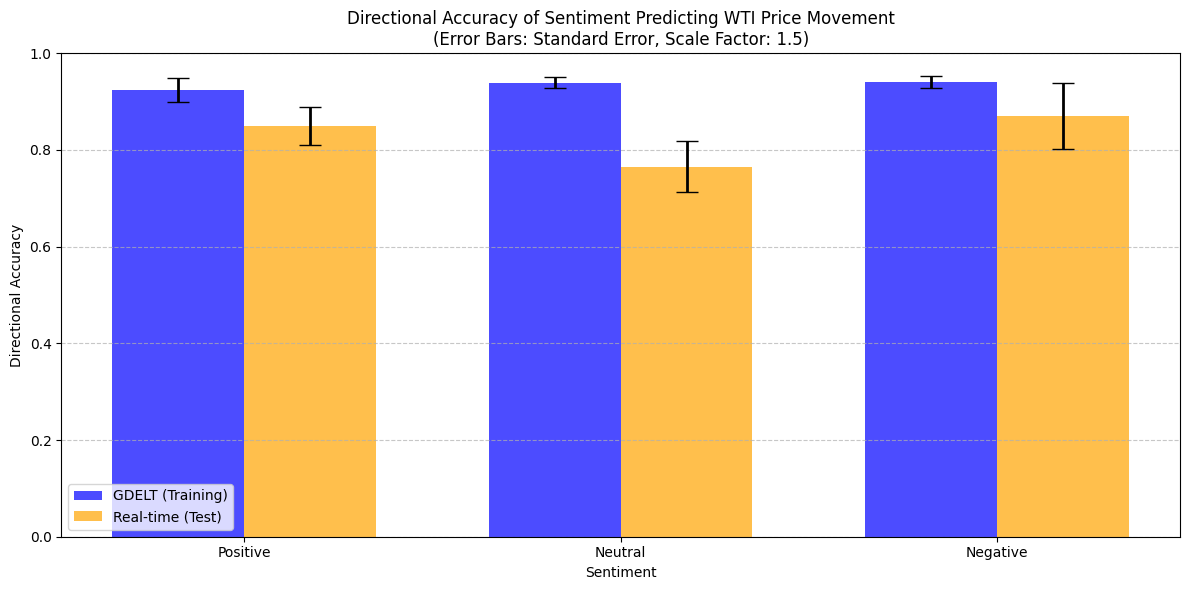

In [ ]:
# Step 4: Implement FNN Model
class FNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, dropout_rate=0.3):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Prepare data for FNN
def prepare_data(df, dataset_name="dataset"):
    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
    df['Sentiment_Numeric'] = df['Article Sentiment'].map(sentiment_map)
    
    logging.info(f"Preparing {dataset_name}: Initial rows = {len(df)}")
    
    df = df.dropna(subset=['Sentiment_Numeric', 'Price_Delta'])
    
    logging.info(f"Preparing {dataset_name}: Rows after dropping NaNs = {len(df)}")
    
    if len(df) == 0:
        logging.warning(f"No valid data in {dataset_name} after dropping NaNs. Check WTI_Price or Price_Delta.")
        return np.array([]), np.array([]), None, None
    
    price_delta_std = df['Price_Delta'].std()
    logging.info(f"{dataset_name} Price_Delta std: {price_delta_std}")
    if price_delta_std < 1e-5:
        logging.warning(f"{dataset_name} has near-zero Price_Delta variance. directional accuracy may be unreliable.")
    
    X = df[['Sentiment_Numeric']].values
    y = df['Price_Delta'].values
    
    X_mean, X_std = X.mean(), X.std() + 1e-8
    y_mean, y_std = y.mean(), y.std() + 1e-8
    X = (X - X_mean) / X_std
    y = (y - y_mean) / y_std
    
    return X, y, df, {'X_mean': X_mean, 'X_std': X_std, 'y_mean': y_mean, 'y_std': y_std}

X_train, y_train, gdelt_df_filtered, train_stats = prepare_data(gdelt_df, "GDELT training set")
X_test, y_test, real_time_df_filtered, test_stats = prepare_data(real_time_df, "real-time test set")

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).reshape(-1, 1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

if X_test.shape[0] == 0 or y_test.shape[0] == 0:
    logging.error("Test set is empty. Cannot evaluate model. Please ensure real_time_df has valid WTI_Price and Price_Delta values.")
else:
    model = FNN(input_size=1, hidden_size=64, dropout_rate=0.3)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 100
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            logging.info(f'Epoch {epoch}, Loss: {loss.item()}')

    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        y_pred_train = model(X_train)
        
        y_pred_test_denorm = y_pred_test.numpy() * test_stats['y_std'] + test_stats['y_mean']
        y_test_denorm = y_test.numpy() * test_stats['y_std'] + test_stats['y_mean']
        y_pred_train_denorm = y_pred_train.numpy() * train_stats['y_std'] + train_stats['y_mean']
        y_train_denorm = y_train.numpy() * train_stats['y_std'] + train_stats['y_mean']
        
        mse_test = mean_squared_error(y_test_denorm, y_pred_test_denorm)
        logging.info(f'Mean Squared Error on Test Set: {mse_test}')
        directional_accuracy_test = np.mean(np.sign(y_pred_test_denorm.flatten()) == np.sign(y_test_denorm.flatten()))
        logging.info(f'Overall Directional Accuracy (Test): {directional_accuracy_test}')

    def plot_sentiment_directional_accuracy(train_df, test_df, model, train_stats, test_stats, n_bootstraps=1000, scale_factor=1.5):
        sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
        sentiments = ['Positive', 'Neutral', 'Negative']
        train_accuracies = []
        train_std_errors = []
        test_accuracies = []
        test_std_errors = []
        
        for dataset, df, stats, prefix in [
            ('train', train_df, train_stats, 'Training'),
            ('test', test_df, test_stats, 'Test')
        ]:
            X_mean, X_std = stats['X_mean'], stats['X_std']
            y_mean, y_std = stats['y_mean'], stats['y_std']
            accuracies = []
            std_errors = []
            
            for sentiment in sentiments:
                sentiment_numeric = sentiment_map[sentiment.lower()]
                mask = df['Sentiment_Numeric'] == sentiment_numeric
                if not mask.any():
                    logging.warning(f"No {prefix} samples for sentiment {sentiment}. Skipping.")
                    accuracies.append(0)
                    std_errors.append(0)
                    continue
                
                X_sent = torch.FloatTensor(df[mask][['Sentiment_Numeric']].values)
                y_sent = df[mask]['Price_Delta'].values
                X_sent = (X_sent - X_mean) / X_std
                
                model.eval()
                with torch.no_grad():
                    y_pred_sent = model(X_sent).numpy() * y_std + y_mean
                
                correct_directions = np.sign(y_pred_sent.flatten()) == np.sign(y_sent)
                accuracy = np.mean(correct_directions)
                
                bootstrap_accs = []
                for _ in range(n_bootstraps):
                    indices = np.random.choice(len(correct_directions), size=len(correct_directions), replace=True)
                    bootstrap_accs.append(np.mean(correct_directions[indices]))
                std_error = np.std(bootstrap_accs) * scale_factor
                
                accuracies.append(accuracy)
                std_errors.append(std_error)
                logging.info(f"{prefix} Sentiment {sentiment}: Directional Accuracy = {accuracy:.3f}, Std Error = {std_error:.3f}")
            
            if dataset == 'train':
                train_accuracies = accuracies
                train_std_errors = std_errors
            else:
                test_accuracies = accuracies
                test_std_errors = std_errors
        
        fig, ax = plt.subplots(figsize=(12, 6))
        bar_width = 0.35
        index = np.arange(len(sentiments))
        
        bars1 = ax.bar(index - bar_width/2, train_accuracies, bar_width, yerr=train_std_errors, capsize=8,
                       label='GDELT (Training)', color='blue', alpha=0.7, error_kw={'elinewidth': 2, 'ecolor': 'black'})
        bars2 = ax.bar(index + bar_width/2, test_accuracies, bar_width, yerr=test_std_errors, capsize=8,
                       label='Real-time (Test)', color='orange', alpha=0.7, error_kw={'elinewidth': 2, 'ecolor': 'black'})
        
        ax.set_xlabel('Sentiment')
        ax.set_ylabel('Directional Accuracy')
        ax.set_title(f'Directional Accuracy of Sentiment Predicting WTI Price Movement\n(Error Bars: Standard Error, Scale Factor: {scale_factor})')
        ax.set_xticks(index)
        ax.set_xticklabels(sentiments)
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
        
        return train_accuracies, train_std_errors, test_accuracies, test_std_errors

    train_accuracies, train_std_errors, test_accuracies, test_std_errors = plot_sentiment_directional_accuracy(
        gdelt_df_filtered, real_time_df_filtered, model, train_stats, test_stats, scale_factor=1.5
    )